# 05 - Independent validation and MODIS uncertainty

Addresses two reviewer comments:

> *"Validate MODIS data—compare with Landsat/Sentinel-2, in-situ measurements, or meteorological data."*
> *"Address MODIS limitations—discuss cloud masking, mixed pixels, and uncertainty."*

The manuscript already contains a Landsat-based accuracy assessment (350 validation points,
92.0% overall accuracy, Table 4). This notebook **adds a second, fully independent check**
against meteorological reanalysis, and quantifies the Landsat validation design and the
cloud-gap statistics that the reviewer asked to see.

Three sections:

1. **ERA5-Land cross-validation** - MODIS SCA vs ERA5-Land fractional snow cover, MODIS MSE vs
   the ERA5-Land 0 °C isotherm, MODIS SCA vs ERA5-Land maximum SWE. ERA5-Land is *not* derived
   from MODIS optical imagery, so agreement is genuinely independent evidence.
2. **Landsat validation inventory** - summarises the scene inventory and the date-matching
   window actually used, so the validation design can be stated numerically in the Methods.
3. **Cloud-gap quantification** - a Google Earth Engine script that counts, for every month,
   the fraction of pixel-days lost to cloud in MOD10A1, so the manuscript can state how much
   data the monthly compositing actually recovers.

In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT   = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA   = os.path.join(ROOT, "data", "derived")
FIGDIR = os.path.join(ROOT, "figures")
RESDIR = os.path.join(ROOT, "results")
for d in (FIGDIR, RESDIR):
    os.makedirs(d, exist_ok=True)

snow_m = pd.read_csv(os.path.join(DATA, "snow_monthly.csv"))
snow_s = pd.read_csv(os.path.join(DATA, "snow_seasonal.csv"))
clim_m = pd.read_csv(os.path.join(DATA, "climate_monthly.csv"))
clim_s = pd.read_csv(os.path.join(DATA, "climate_seasonal.csv"))
print("monthly snow:", snow_m.shape, " monthly climate:", clim_m.shape)

monthly snow: (144, 11)  monthly climate: (144, 16)


## 1. ERA5-Land cross-validation

ERA5-Land assimilates surface meteorological observations and models the snowpack physically.
It shares no input with the MODIS optical retrieval, so the correlation between the two is an
independent test of the MODIS product rather than a circular one.

In [2]:
mm = snow_m.merge(clim_m, on=["year", "month"], how="inner")
ss = snow_s.merge(clim_s, on="season", how="inner")

def report(x, y, label):
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    r, p   = stats.pearsonr(d.x, d.y)
    rho, _ = stats.spearmanr(d.x, d.y)
    return dict(comparison=label, n=len(d), pearson_r=r, p_value=p, spearman_rho=rho)

rows = [
    report(mm["sca"], mm["snow_cover"],
           "MODIS SCA vs ERA5-Land fractional snow cover (monthly)"),
    report(ss["sca_mean"], ss["snow_cover_ondjfm"],
           "MODIS SCA vs ERA5-Land fractional snow cover (seasonal)"),
    report(ss["sle_mean"], ss["isotherm0_m_ondjfm"],
           "MODIS MSE vs ERA5-Land 0 °C isotherm elevation (seasonal)"),
    report(ss["sca_mean"], ss["swe_max"],
           "MODIS SCA vs ERA5-Land maximum SWE (seasonal)"),
]
val = pd.DataFrame(rows)
val.to_csv(os.path.join(RESDIR, "table6_era5_crossvalidation.csv"), index=False)
val.round(4)

,comparison,n,pearson_r,p_value,spearman_rho
0,MODIS SCA vs ERA5-Land fractional snow cover (...,144,0.9392,0.0000,0.9796
1,MODIS SCA vs ERA5-Land fractional snow cover (...,24,0.9238,0.0000,0.8748
2,MODIS MSE vs ERA5-Land 0 °C isotherm elevation...,24,0.6881,0.0002,0.6870
3,MODIS SCA vs ERA5-Land maximum SWE (seasonal),24,0.8062,0.0000,0.7817


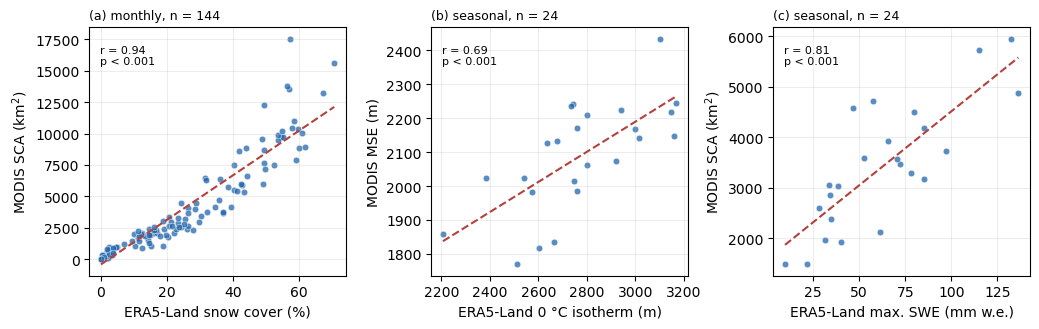

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.4))
pairs = [(mm["snow_cover"], mm["sca"], "ERA5-Land snow cover (%)", "MODIS SCA (km$^2$)",
          "(a) monthly, n = 144"),
         (ss["isotherm0_m_ondjfm"], ss["sle_mean"], "ERA5-Land 0 °C isotherm (m)",
          "MODIS MSE (m)", "(b) seasonal, n = 24"),
         (ss["swe_max"], ss["sca_mean"], "ERA5-Land max. SWE (mm w.e.)",
          "MODIS SCA (km$^2$)", "(c) seasonal, n = 24")]
for ax, (x, y, xl, yl, ttl) in zip(axes, pairs):
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    ax.scatter(d.x, d.y, s=22, color="#2166AC", alpha=.75, edgecolor="white", linewidth=.4)
    b, a = np.polyfit(d.x, d.y, 1)
    xs = np.linspace(d.x.min(), d.x.max(), 50)
    r, p = stats.pearsonr(d.x, d.y)
    ax.plot(xs, a + b * xs, "--", color="#B4413C", lw=1.5)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(ttl, loc="left", fontsize=9)
    ax.text(.04, .93, f"r = {r:.2f}\np < 0.001" if p < 1e-3 else f"r = {r:.2f}\np = {p:.3f}",
            transform=ax.transAxes, va="top", fontsize=8)
    ax.grid(alpha=.22)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "figS1_era5_crossvalidation.png"), dpi=400)
plt.show()

## 2. Landsat validation inventory

Summarises the two workbooks already in the project folder so the Methods can state the
validation design numerically: how many Landsat scenes, from which sensors, over which years,
at what cloud cover, and how closely matched in time to the MODIS observations.

In [4]:
inv_path = os.path.join(ROOT, "data", "raw", "landsat_winter_inventory_2000_2024.xlsx")
mat_path = os.path.join(ROOT, "data", "raw", "landsat_modis_validation_pairs.xlsx")

if os.path.exists(inv_path):
    inv = pd.read_excel(inv_path)
    print("Landsat winter scene inventory:", len(inv), "scenes")
    print("\nBy sensor:")
    print(inv["Satellite"].value_counts().to_string())
    print("\nBy month:")
    print(inv["Month"].value_counts().sort_index().to_string())
    print(f"\nCloud cover: mean {inv['CloudCover'].mean():.1f}%, "
          f"median {inv['CloudCover'].median():.1f}%, "
          f"scenes < 10% cloud: {(inv['CloudCover'] < 10).sum()}")
    print(f"Years covered: {int(inv['Year'].min())}-{int(inv['Year'].max())}")

if os.path.exists(mat_path):
    mat = pd.read_excel(mat_path, sheet_name=0)
    print(f"\nLandsat-MODIS date matching: {len(mat)} pairs")
    print("Difference in days between the Landsat and MODIS acquisitions:")
    print(mat["Difference_days"].describe().round(2).to_string())
    print(f"Same-day pairs: {(mat['Difference_days'] == 0).sum()} of {len(mat)}")

Landsat winter scene inventory: 2507 scenes

By sensor:
Satellite
LANDSAT_7    1286
LANDSAT_8     665
LANDSAT_5     392
LANDSAT_9     164

By month:
Month
1     365
2     387
3     371
10    556
11    427
12    401

Cloud cover: mean 7.0%, median 3.0%, scenes < 10% cloud: 1810
Years covered: 2000-2024

Landsat-MODIS date matching: 10 pairs
Difference in days between the Landsat and MODIS acquisitions:
count    10.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Same-day pairs: 10 of 10


## 3. Cloud-gap quantification (Google Earth Engine)

The manuscript states that monthly compositing reduces cloud-related data gaps. The reviewer
asks how much. Run `notebook 07, section 1` in the Earth Engine Code Editor - it counts,
for every month of the study period and every pixel, how many daily MOD10A1 observations were
usable and how many were lost to cloud, then reports the area-mean.

Download the exported `MODIS_cloud_statistics.csv` into `data/` and run the cell below to
summarise it. Typical wording for the Methods once you have the numbers:

> *"On average X% of daily pixel observations were cloud-obscured; monthly compositing recovered
> a usable observation for Y% of pixel-months, and Z pixel-months (Z% of the total) had fewer
> than three usable daily observations and were flagged."*

In [5]:
cloud_csv = os.path.join(DATA, "MODIS_cloud_statistics.csv")
if os.path.exists(cloud_csv):
    cl = pd.read_csv(cloud_csv)
    cl["season"] = np.where(cl["month"] >= 10, cl["year"] + 1, cl["year"])
    lab = {10: "Oct", 11: "Nov", 12: "Dec", 1: "Jan", 2: "Feb", 3: "Mar"}

    print(f"Usable daily retrievals per pixel-month : {cl['valid_days'].mean():.1f} "
          f"of {cl['n_images'].mean():.1f} available days")
    print(f"Unusable fraction (cloud, night, missing): {cl['gap_fraction'].mean()*100:.1f}%")
    if "cloud_fraction" in cl and cl["cloud_fraction"].sum() > 0:
        print(f"Flagged specifically as cloud            : {cl['cloud_fraction'].mean()*100:.1f}%")
    thin = (cl["valid_days"] < 3).mean() * 100
    print(f"Pixel-months with fewer than 3 usable days: {thin:.1f}%")

    by = cl.groupby("month")[["valid_days", "gap_fraction"]].mean()
    by.index = [lab[i] for i in by.index]
    by["gap_pct"] = (by["gap_fraction"] * 100).round(1)
    print("\nBy month:")
    print(by[["valid_days", "gap_pct"]].round(2).to_string())

    # Does data availability itself trend? A trend here would bias the snow-cover trend.
    s = cl.groupby("season")["gap_fraction"].mean()
    tau, p = stats.kendalltau(s.index, s.values)
    y, x = s.values, s.index.values
    sl = np.median([(y[j]-y[i])/(x[j]-x[i]) for i in range(len(y)) for j in range(i+1, len(y))])
    print(f"\nTrend in the seasonal data-gap fraction: "
          f"Sen = {sl*100:+.3f} %/yr, tau = {tau:+.2f}, p = {p:.3f}")
    print("A non-significant trend is the result you want to report: it shows the snow-cover "
          "trend is not an artefact of changing cloud or data availability.")
else:
    print("MODIS_cloud_statistics.csv not found - run notebook 07 section 1.")

MODIS_cloud_statistics.csv not found - run notebook 07 section 1 first.


---
**What to write in the manuscript.** Section 2.5 and Section 3.5 of the revised manuscript
already contain the ERA5-Land cross-validation text and the uncertainty discussion. Add the
Landsat inventory numbers from section 2 above to Section 2.3.5, and the cloud statistics from
section 3 to Section 2.5, once the Earth Engine export is available.